# TFM

## Importación de librerías

In [ ]:
!pip install --upgrade tensorflow


In [ ]:
!pip show tensorflow
!pip show keras

In [ ]:
import pandas as pd
import numpy as np
import os
from glob import glob
import itertools
import fnmatch
import random
import math
import matplotlib.pylab as plt
import seaborn as sns
import cv2
import sklearn
import keras
import tensorflow as tf

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score


## **Preparación del dataset**


In [ ]:
# Rutas a las carpetas
data_dir = '/content/dataset/'

# Lista de todas las clases
clases = os.listdir(data_dir)
clases.remove('.ipynb_checkpoints')

# Listas para almacenar las rutas de las imágenes y las etiquetas
image_paths = []
labels = []

# Recorrer cada clase y agregar las rutas de las imágenes y etiquetas correspondientes
for clase in clases:
    clase_path = os.path.join(data_dir, clase)
    images = os.listdir(clase_path)
    image_paths += [os.path.join(clase_path, img) for img in images]
    labels += [clase] * len(images)

In [ ]:
# Convertir etiquetas a números (opcional)
label_to_index = {label: idx for idx, label in enumerate(clases)}
numeric_labels = [label_to_index[label] for label in labels]

# Dividir en entrenamiento y validación (80% - 20%)
train_paths, val_paths, train_labels, val_labels = train_test_split(image_paths, numeric_labels, test_size=0.2, stratify=numeric_labels)

# Crear generadores de datos personalizados a partir de las rutas
train_datagen = ImageDataGenerator(rescale=1.0/255)
val_datagen = ImageDataGenerator(rescale=1.0/255)

def custom_generator(paths, labels, batch_size, datagen):
    while True:
        # Mezclar los datos en cada iteración
        indices = np.arange(len(paths))
        np.random.shuffle(indices)
        for i in range(0, len(paths), batch_size):
            batch_indices = indices[i:i + batch_size]
            batch_paths = [paths[j] for j in batch_indices]
            batch_labels = [labels[j] for j in batch_indices]
            # batch_images = [datagen.flow_from_directory(batch_paths)]

            batch_images = []
            for path in batch_paths:
                img = load_img(path, target_size=(224, 224))  # Ajusta el tamaño según tu modelo
                img_array = img_to_array(img)
                img_array = datagen.random_transform(img_array)  # Aplicar aumentaciones
                img_array = datagen.standardize(img_array)  # Aplicar normalización (rescale)
                batch_images.append(img_array)

            yield np.array(batch_images), np.array(batch_labels)

train_generator = custom_generator(train_paths, train_labels, batch_size=32, datagen=train_datagen)
val_generator = custom_generator(val_paths, val_labels, batch_size=32, datagen=val_datagen)

In [ ]:
def display_examples(class_names, images, labels):
    """
        Display 25 images from the images array with its corresponding labels
    """

    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[labels[i]])
    plt.show()

(32, 224, 224, 3) (32,)


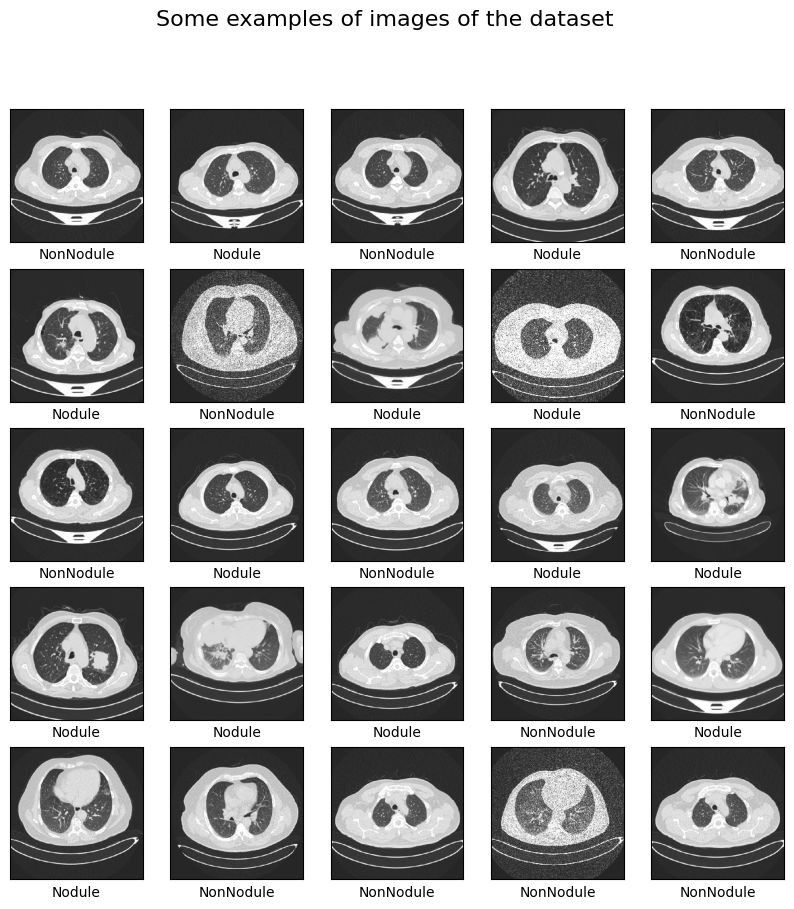

In [ ]:
# Get one batch of data
images, labels = next(train_generator)

print(images.shape, labels.shape)

display_examples(clases, images, labels)

## **Definir y entrenar el modelo CNN**



In [ ]:
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
#     tf.keras.layers.MaxPooling2D(2, 2),

#     tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(2, 2),

#     tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D(2, 2),

#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(512, activation='relu'),
#     tf.keras.layers.Dense(1, activation='sigmoid')  # Para clasificación binaria, usa 'softmax' para múltiples clases
# ])

# Definir la entrada
inputs = tf.keras.Input(shape=(224, 224, 3))

# Capas convolucionales con MaxPooling
x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu')(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

# Aplanamos el resultado
x = tf.keras.layers.Flatten()(x)

# # Capa densa intermedia
x = tf.keras.layers.Dense(512, activation='relu')(x)

# Congelamos esta parte del modelo
# x.trainable = False

# Capa de salida, para clasificación binaria o multiclase
x = tf.keras.layers.Dense(2, activation='softmax')(x)  # Para binario, si es multiclase, usa softmax y ajusta el número de neuronas

# Definir el modelo
model = tf.keras.Model(inputs, x)

# Compilar el modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Resumen del modelo
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │           1,026 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,397,122 (169.36 MB)

 Trainable params: 44,397,122 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
checkpoints = ModelCheckpoint('modelo.keras', monitor='val_loss', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=10)
callbacks_list = [checkpoints, early_stop]

history = model.fit(
    train_generator,
    steps_per_epoch=len(train_paths) // 32,
    validation_data=val_generator,
    validation_steps=len(val_paths) // 32,
    epochs=10,
    callbacks=callbacks_list,
    shuffle=True
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 137s 5s/step - accuracy: 0.6235 - loss: 2.0094 - val_accuracy: 0.7292 - val_loss: 0.5221
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.7706 - loss: 0.4656 - val_accuracy: 0.8830 - val_loss: 0.3356
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 123s 5s/step - accuracy: 0.9158 - loss: 0.2549 - val_accuracy: 0.9468 - val_loss: 0.1988
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.9694 - loss: 0.1162 - val_accuracy: 0.9681 - val_loss: 0.1389
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 127s 5s/step - accuracy: 0.9803 - loss: 0.0637 - val_accuracy: 0.9840 - val_loss: 0.0659
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 116s 4s/step - accuracy: 0.9972 - loss: 0.0290 - val_accuracy: 0.9734 - val_loss: 0.0768
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - accuracy: 0.9780 - loss: 0.0678 - val_accuracy: 0.9787 - val_loss: 0.0619
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 155s 6s/step - accuracy: 0.9960 - loss: 0.0191 - val_accuracy: 0.9844 - v

**Gráficos de evolución del modelo**

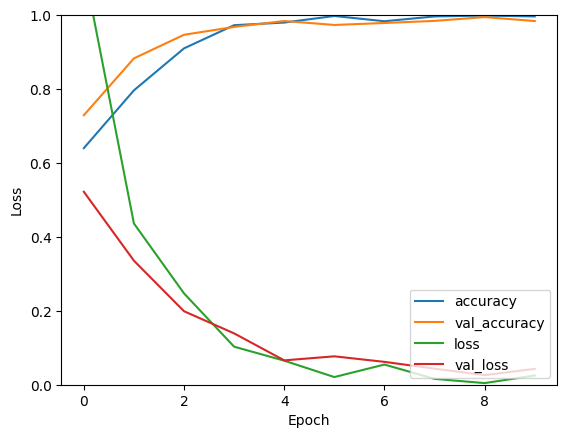

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

# Loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='lower right')

#### Evaluando el modelo

In [ ]:
model = tf.keras.models.load_model('modelo.keras')


Precision: 0.99
Recall: 1.00
F1 Score: 0.99
Accuracy: 0.99



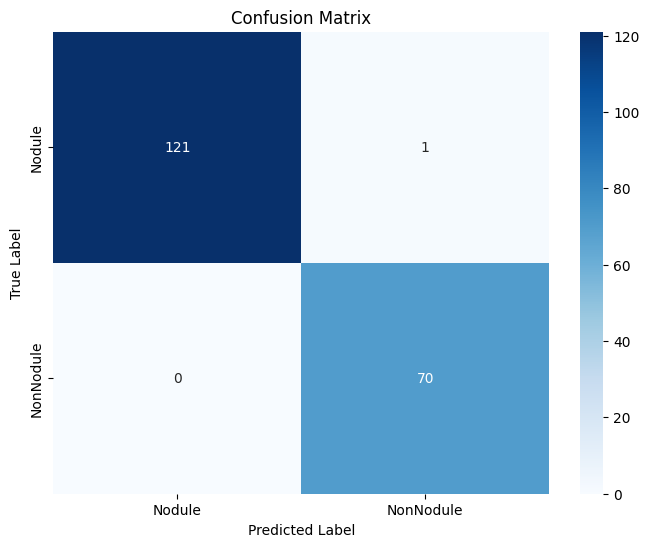

In [ ]:
val_steps = len(val_paths) // 32

y_true = []
y_pred = []
for i in range(val_steps):
  images, labels = next(val_generator)
  predictions = model.predict(images, verbose=0)
  # predict_classes = (predictions > 0.5).astype("int32")
  predict_classes = np.argmax(predictions, axis=1)
  y_true.extend(labels)
  y_pred.extend(predict_classes)

# Convert to NumPy arrays for easier handling
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calcular métricas de evaluación
precision = precision_score(y_true, y_pred, average='binary')  # 'micro' o 'macro' si tienes más clases
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')
accuracy = accuracy_score(y_true, y_pred)

# Imprimir resultados
print('')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Accuracy: {accuracy:.2f}')  # Imprimir exactitud
print('')

# Generar la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
# Replace val_generator.class_indices.keys() with your actual class labels
class_labels = ['Nodule', 'NonNodule'] # Update this with your actual class names
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

## **Modelos Preentrenados de Keras y Evaluación**

#### **Modelo VGG16**

In [ ]:
# Cargar la arquitectura de VGG16 preentrenada (excluyendo la parte superior/fully connected)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Congelar las capas de VGG16 para que no se entrenen
for layer in base_model.layers:
    layer.trainable = False

# Crear un nuevo modelo secuencial y añadir la base de VGG16
modelVGG = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),  # Añadir una capa densa (puedes ajustar el número de neuronas)
    Dense(1, activation='sigmoid')  # Capa de salida (ajusta para múltiples clases)
])

modelVGG.summary()

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.vgg16.VGG16(
    input_tensor=inputs,
    include_top=False,
    weights='imagenet'
)

x.trainable = False

x = tf.keras.layers.Flatten()(x.output)
x = tf.keras.layers.Dense(2, activation='sigmoid')(x)

modelVGG = tf.keras.Model(inputs, x)

modelVGG.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │          50,178 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
#####
checkpoints = ModelCheckpoint('modeloVGG.keras', monitor='val_loss', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=10)
callbacks_list = [checkpoints, early_stop]
#####

# adam = tf.keras.optimizers.Adam(learning_rate=0.0001)
# model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer=adam)

# Compilar el modelo
modelVGG.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = modelVGG.fit(
    train_generator,
    steps_per_epoch=len(train_paths) // 32,  # Replace 32 with your actual batch size
    validation_data=val_generator,
    validation_steps=len(val_paths) // 32,  # Replace 32 with your actual batch size
    epochs=10,  # Adjust the number of epochs as needed
    callbacks=callbacks_list,
    shuffle=True
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 573s 21s/step - accuracy: 0.6746 - loss: 0.9132 - val_accuracy: 0.8883 - val_loss: 0.3055
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 572s 21s/step - accuracy: 0.8615 - loss: 0.3222 - val_accuracy: 0.8989 - val_loss: 0.2281
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 569s 21s/step - accuracy: 0.9384 - loss: 0.1545 - val_accuracy: 0.9574 - val_loss: 0.1413
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 571s 21s/step - accuracy: 0.9649 - loss: 0.1234 - val_accuracy: 0.9583 - val_loss: 0.1311
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 567s 21s/step - accuracy: 0.9744 - loss: 0.1055 - val_accuracy: 0.9255 - val_loss: 0.1593
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 568s 21s/step - accuracy: 0.9795 - loss: 0.0722 - val_accuracy: 0.9787 - val_loss: 0.0879
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 564s 21s/step - accuracy: 0.9885 - loss: 0.0653 - val_accuracy: 0.9734 - val_loss: 0.0988
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 564s 21s/step - accuracy: 0.9992 - loss: 0.0384 - val_accuracy: 0.

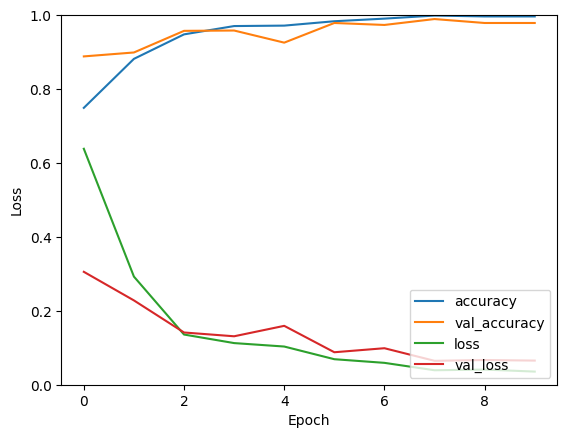

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

# Loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
modelVGG = tf.keras.models.load_model('modeloVGG.keras')


Precision: 0.97
Recall: 1.00
F1 Score: 0.99
Accuracy: 0.99



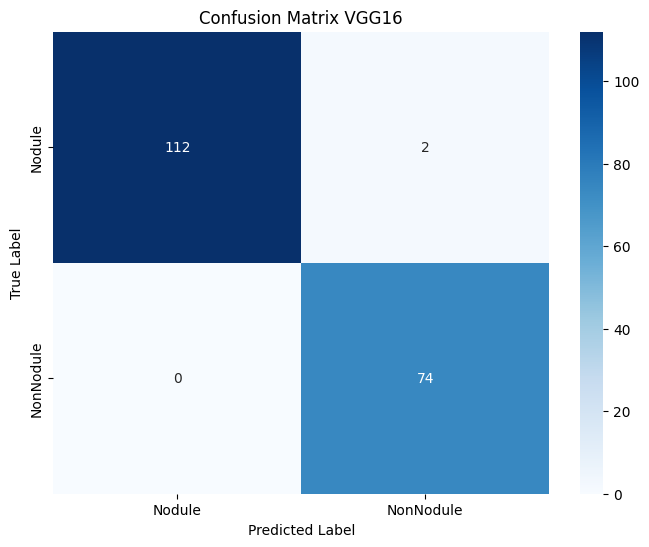

In [ ]:
val_steps = len(val_paths) // 32  # Ajusta esto si usas otro tamaño de batch

y_true = []
y_pred = []
for i in range(val_steps):
  images, labels = next(val_generator)
  predictions = modelVGG.predict(images, verbose=0)
  # predict_classes = (predictions > 0.5).astype("int32")
  predict_classes = np.argmax(predictions, axis=1)

  y_true.extend(labels)
  y_pred.extend(predict_classes)

# Convert to NumPy arrays for easier handling
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calcular métricas de evaluación
precision = precision_score(y_true, y_pred, average='binary')  # 'micro' o 'macro' si tienes más clases
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')
accuracy = accuracy_score(y_true, y_pred)
# Imprimir resultados
print('')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Accuracy: {accuracy:.2f}')  # Imprimir exactitud
print('')

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
# Replace val_generator.class_indices.keys() with your actual class labels
class_labels = ['Nodule', 'NonNodule'] # Update this with your actual class names
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix VGG16')
plt.show()

#### **Modelo Xception**

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = tf.keras.applications.xception.Xception(
    input_tensor=inputs,
    include_top=False,
    weights='imagenet'
)

x.trainable = False

x = tf.keras.layers.Flatten()(x.output)
x = tf.keras.layers.Dense(2, activation='softmax')(x) # 1, sigmoid

modelXce = tf.keras.Model(inputs, x)

modelXce.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 111, 111, 32)   │            864 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 111, 111, 32)   │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 111, 111, 32)   │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 109, 109, 64)   │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 109, 109, 64)   │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 109, 109, 64)   │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 109, 109, 128)  │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 109, 109, 128)  │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 109, 109, 128)  │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 109, 109, 128)  │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 55, 55, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 55, 55, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 21,062,186 (80.35 MB)

 Trainable params: 200,706 (784.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
#####
checkpoints = ModelCheckpoint('modeloXce.keras', monitor='val_loss', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=10)
callbacks_list = [checkpoints, early_stop]
#####

# adam = tf.keras.optimizers.Adam(learning_rate=0.0001)
# model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer=adam)

# Compilar el modelo
modelXce.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # binary_crossentropy - sparse_categorical_crossentropy

In [ ]:
history = modelXce.fit(
    train_generator,
    steps_per_epoch=len(train_paths) // 32,  # Replace 32 with your actual batch size
    validation_data=val_generator,
    validation_steps=len(val_paths) // 32,  # Replace 32 with your actual batch size
    epochs=10,  # Adjust the number of epochs as needed
    callbacks=callbacks_list,
    shuffle=True
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 238s 8s/step - accuracy: 0.7300 - loss: 2.5724 - val_accuracy: 0.8989 - val_loss: 0.7585
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 219s 8s/step - accuracy: 0.9104 - loss: 0.6111 - val_accuracy: 0.8989 - val_loss: 0.7714
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 217s 8s/step - accuracy: 0.9470 - loss: 0.3579 - val_accuracy: 0.9574 - val_loss: 0.2452
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 220s 8s/step - accuracy: 0.9843 - loss: 0.0732 - val_accuracy: 0.9043 - val_loss: 0.4136
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 217s 8s/step - accuracy: 0.9932 - loss: 0.0244 - val_accuracy: 0.9202 - val_loss: 0.3989
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 216s 8s/step - accuracy: 0.9870 - loss: 0.0732 - val_accuracy: 0.9628 - val_loss: 0.1232
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 218s 8s/step - accuracy: 0.9926 - loss: 0.0112 - val_accuracy: 0.9635 - val_loss: 0.0880
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 217s 8s/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 0.9894 - v

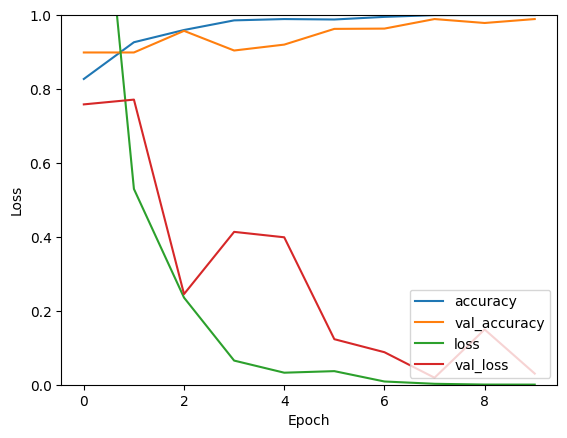

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

# Loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])
plt.legend(loc='lower right')

In [ ]:
modelXce = tf.keras.models.load_model('modeloXce.keras')


Precision: 1.00
Recall: 1.00
F1 Score: 1.00
Accuracy: 1.00



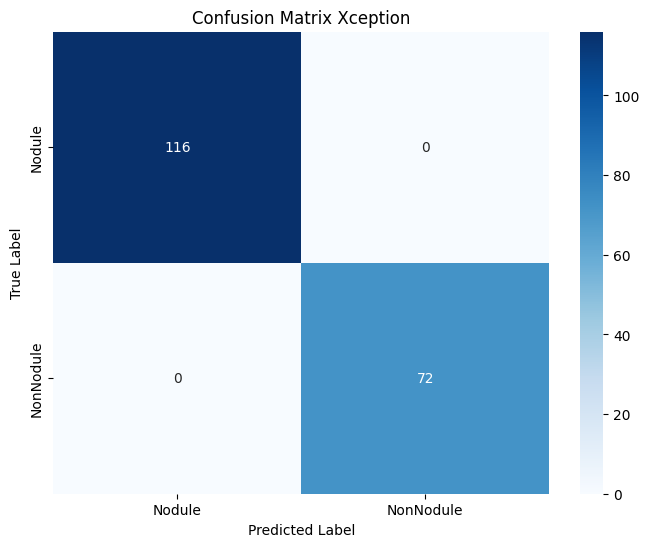

In [ ]:
val_steps = len(val_paths) // 32  # Ajusta esto si usas otro tamaño de batch

y_true = []
y_pred = []
for i in range(val_steps):
  images, labels = next(val_generator)
  predictions = modelXce.predict(images, verbose=0)
  # predict_classes = (predictions > 0.5).astype("int32")
  # Use argmax to get the predicted class for binary classification
  predict_classes = np.argmax(predictions, axis=1)
  y_true.extend(labels)
  y_pred.extend(predict_classes)

# Convert to NumPy arrays for easier handling
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calcular métricas de evaluación
precision = precision_score(y_true, y_pred, average='binary')  # 'micro' o 'macro' si tienes más clases
recall = recall_score(y_true, y_pred, average='binary')
f1 = f1_score(y_true, y_pred, average='binary')
accuracy = accuracy_score(y_true, y_pred)
# Imprimir resultados
print('')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Accuracy: {accuracy:.2f}')  # Imprimir exactitud
print('')

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
# Replace val_generator.class_indices.keys() with your actual class labels
class_labels = ['Nodule', 'NonNodule'] # Update this with your actual class names
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Xception')
plt.show()

## **Evaluación Modelos**

In [ ]:
model = tf.keras.models.load_model('modeloXce.keras')

In [ ]:
model = tf.keras.models.load_model('modeloVGG.keras')

In [ ]:
model = tf.keras.models.load_model('modelo.keras')

In [ ]:
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_generator = test_datagen.flow_from_directory(
    '/content/dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

In [ ]:
test_data = os.listdir('/content/test/images/')

In [ ]:
def data_read_class(path):
  with open(path, 'r') as f:
    labels = f.read().split()
    class_label = labels[0]
  return class_label


In [ ]:
TP = 0
TN = 0
FP = 0
FN = 0

for i in range(len(test_data)):
  img = load_img('/content/test/images/' + test_data[i], target_size=(224, 224))
  img_array = img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0

  prediction = model.predict(img_array)

  if np.argmax(prediction[0]) > 0.5:
    predicted_class = 1
  else:
    predicted_class = 0

  if int(data_read_class(f'/content/test/labels/{test_data[i].replace(".jpg", ".txt")}')) == predicted_class:
    if predicted_class == 0: # La etiqueta 0 corresponde con la clase positiva -> Presencia de tumor
      TP += 1
    else:
      TN += 1
  else:
    if predicted_class == 0:
      FP += 1
    else:
      FN += 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━

In [ ]:
cm = np.array([[TP, FN], [FP, TN]])
print(cm)

[[118  32]
 [  0  50]]



Accuracy: 0.84
Precision: 1.00
Recall: 0.79
F1 Score: 0.88



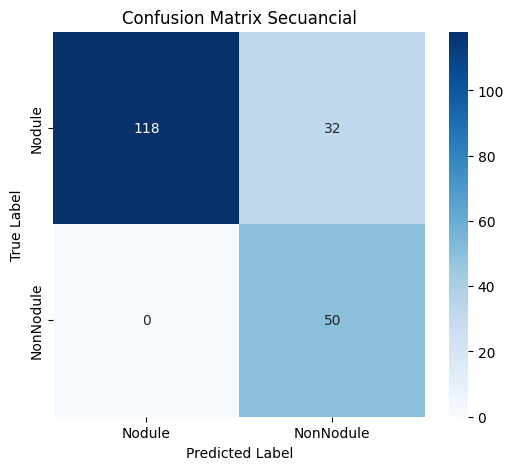

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}\n")

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
# Replace val_generator.class_indices.keys() with your actual class labels
class_labels = ['Nodule', 'NonNodule'] # Update this with your actual class names
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Secuancial')
plt.show()


Accuracy: 0.96
Precision: 1.00
Recall: 0.95
F1 Score: 0.97



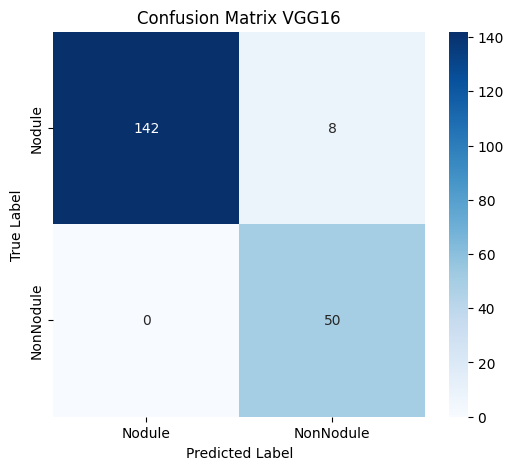

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}\n")

plt.figure(figsize=(6, 5))
class_labels = ['Nodule', 'NonNodule']
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix VGG16')
plt.show()


Accuracy: 0.88
Precision: 1.00
Recall: 0.84
F1 Score: 0.91



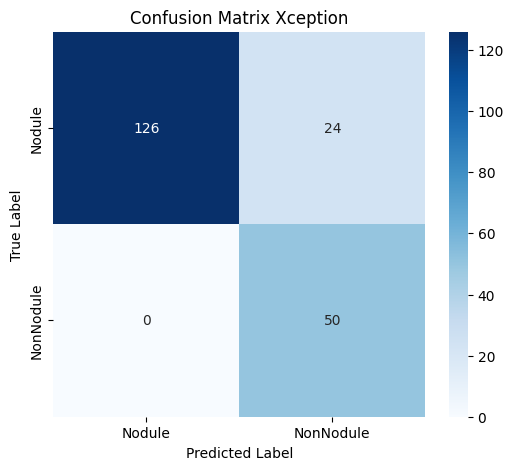

In [ ]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

print(f"\nAccuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1_score:.2f}\n")

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 5))
class_labels = ['Nodule', 'NonNodule']
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Xception')
plt.show()

## **Grad-Cam**

In [ ]:
class GradCam():

  def __init__(self, model, last_conv_layer_name):

        self.model = model
        self.last_conv_layer_name = last_conv_layer_name

        # get the layer object of the last convolutionl layer
        last_conv_layer = self.model.get_layer(self.last_conv_layer_name).output

        # create a model that maps the input image to the activations
        # of the last conv layer as well as the output predictions
        self.grad_model = tf.keras.models.Model(
            [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])



  def compute_heatmap(self, img_array, pred_index=None):

        '''
        Purpose:
            Get the class level activations heatmap for the CNN network. The activation maps help us
            identify & localize the regions, patterns of the image the neural network looks at, and
            activates the region around the patterns. To visualize the activation maps, this function
            works on the output of the LAST CONVOLUTIONAL LAYER and the final CLASSIFICATION LAYERS.

        Parameters:
            1. img_array - the array representation of the image for which the activation maps are to be
                           visualized.
            2. model - the CNN model whose activations are to be analyzed.
            3. last_conv_layer_name - name of the last convolutional layer of the model.
            4. pred_index (optional): The index of the largest value in the tensor.
                                      The unit which contributed the most towards the predicted result.

        Return Value:
            heatmap - The heatmap showing the more active regions the CNN looked at in deciding the class
                      for the image.

        '''

        # Compute the gradient of the top predicted class for our input image
        # with respect to the activations of the last conv layer
        with tf.GradientTape() as tape:
            last_conv_layer_output, preds = self.grad_model(img_array)
            tensor_preds = preds[0]
            if pred_index is None:
                pred_index = tf.argmax(tensor_preds[0]) # returns the index of the largest value in the tensor.
            class_channel = tensor_preds[:, pred_index]

            # last_conv_layer_output, preds = self.grad_model(img_array)
            # if pred_index is None:
            #     pred_index = tf.argmax(preds[0]) # returns the index of the largest value in the tensor.
            # class_channel = preds[:, pred_index]

        # return [last_conv_layer_output]

        # This is the gradient of the output neuron (top predicted or chosen)
        # with regard to the output feature map of the last conv layer
        grads = tape.gradient(class_channel, last_conv_layer_output)

        # This is a vector where each entry is the mean intensity of the gradient
        # over a specific feature map channel.
        # get the mean of elements across dimensions of a tensor.
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        # We multiply each channel in the feature map array
        # by "how important this channel is" with regard to the top predicted class
        # then sum all the channels to obtain the heatmap class activation
        last_conv_layer_output = last_conv_layer_output[0]
        heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        # For visualization purpose, we will also normalize the heatmap between 0 & 1
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

        return heatmap.numpy()

  def GetSuperImposedCAMImage(self, heatmap, image, alpha = 0.5):

        ''''
        Purpose:
            Get the super imposed or the blended version of the image comprising of the class activations
            heatmap and the original image.

        Parameters:
            1. heatmap - The class activation heatmap for the concerned image.
            2. image - The original image for which the activation image is being calculated.
            3. alpha (optional) - A number between 0 & 1 to control the weighted blending of the images.

        Return Value:
            superImposedImage - The blended version of the original image and the corresponding class
                                activation map.

        '''

        # Rescale the image to 0-255
        image = image * 255

        # Rescale heatmap to 0-255
        # Resize to the size of the image
        # Apply colormap
        heatmap = np.uint8(255 * heatmap)

        # upsample the class actiavtion to match the size of the original image
        # before the 2 images can be blended for final visualization.
        heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))

        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # Superimpose the heatmap on original image
        superImposedImage = heatmap * alpha + image
        superImposedImage = tf.keras.preprocessing.image.array_to_img(superImposedImage)

        return superImposedImage


  def DisplaySuperImposedImages(self, image, heatmap,superimposed_img):

      '''
      Purpose:
          Display the original image and the corresponding class activation blended image.

      Parameters:
          1. image - The original image for which the activation image is being calculated.
          2. superimposed_img - The blended version of the original image and the corresponding class
                                activation map.

      Return Value:
          NONE

      '''

      fig, ax = plt.subplots(1, 3, figsize=(8, 12))

      ax[0].imshow(image)
      ax[1].imshow(heatmap)
      ax[2].imshow(superimposed_img)

      ax[0].title.set_text('Original\nImage')
      ax[1].title.set_text('Class Activation\nHeatmap')
      ax[2].title.set_text('Class Activation\nBlended Image')

      ax[0].axis('off')
      ax[1].axis('off')
      ax[2].axis('off')



In [ ]:
imagen = f'/content/test/images/{test_data[0]}'
load_image = cv2.imread(imagen)
img = cv2.cvtColor(load_image, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))
img = cv2.normalize(img, None, 0, 1.0, cv2.NORM_MINMAX, dtype = cv2.CV_32F)

##### G-CAM Xception

In [ ]:
model = tf.keras.models.load_model('modeloXce.keras')

In [ ]:
gCamXception = GradCam(model, "block14_sepconv2")

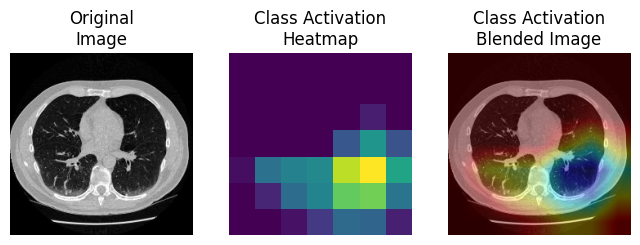

In [ ]:
# reshape img to a tensor of shape (1, 128, 128, 3)
imgAsTensor = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))

# generate the heatmap
heatmap = gCamXception.compute_heatmap(imgAsTensor)

superImposedImg = gCamXception.GetSuperImposedCAMImage(heatmap = heatmap, image = img)
gCamXception.DisplaySuperImposedImages(image = img, heatmap = heatmap, superimposed_img = superImposedImg)

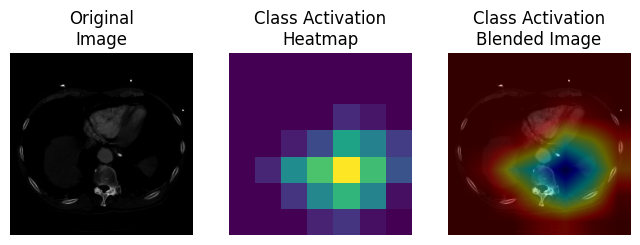

In [ ]:
# generate the heatmap
heatmap = gCamXception.compute_heatmap(imgAsTensor)

superImposedImg = gCamXception.GetSuperImposedCAMImage(heatmap = heatmap, image = img)
gCamXception.DisplaySuperImposedImages(image = img, heatmap = heatmap, superimposed_img = superImposedImg)

##### G-CAM VGG

In [ ]:
model = tf.keras.models.load_model('modeloVGG.keras')

In [ ]:
gCamVgg = GradCam(model, "block5_conv3")

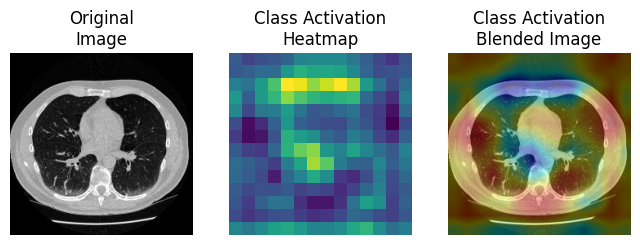

In [ ]:
imgAsTensor = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))

# generate the heatmap
heatmap = gCamVgg.compute_heatmap(imgAsTensor)

superImposedImg = gCamVgg.GetSuperImposedCAMImage(heatmap = heatmap, image = img)
gCamVgg.DisplaySuperImposedImages(image = img, heatmap = heatmap, superimposed_img = superImposedImg)

##### G-CAM Secuencial

In [ ]:
model = tf.keras.models.load_model('modelo.keras')

In [ ]:
gCamSeq = GradCam(model, "conv2d_8")

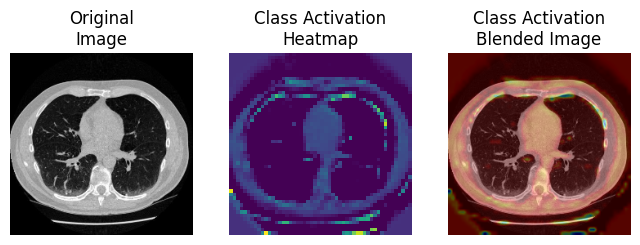

In [ ]:
imgAsTensor = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))

# generate the heatmap
heatmap = gCamSeq.compute_heatmap(imgAsTensor)

superImposedImg = gCamSeq.GetSuperImposedCAMImage(heatmap = heatmap, image = img)
gCamSeq.DisplaySuperImposedImages(image = img, heatmap = heatmap, superimposed_img = superImposedImg)

## **Cálculo IoU**

##### Crear subconjunto para las pruebas

Definir subconjunto de datos a dentro del de test en el que se conocen las anotacoines correspondientes con las localizaciones

In [ ]:
def txt_yolo_check(file_path):

  with open(file_path, 'r') as file:
    data = file.read()
    labels = data.split()
    if len(labels) > 2:
      return True
    else:
      return False

In [ ]:
test_labels = os.listdir('/content/test/labels/')
total_iou_data = []

for label in test_labels:
  if txt_yolo_check(f'/content/test/labels/{label}'):
    total_iou_data.append(label)

print(len(total_iou_data))

120


##### Funciones

In [ ]:
from google.colab.patches import cv2_imshow

def read_txt(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
        result = []
        for line in lines:
          labels = line.split()
          coordenates = [float(labels[1]), float(labels[2]), float(labels[3]), float(labels[4])]
          result.append(coordenates)
    return result


# Función para convertir formato YOLO a una máscara binaria
def yolo_to_mask(yolo_coords, img_shape):
    """
    Convierte coordenadas YOLO a una máscara binaria.
    :param yolo_coords: Lista [class_id, x_center, y_center, width, height] en formato YOLO.
    :param img_shape: Tamaño de la imagen original (altura, ancho).
    :return: Máscara binaria con el bounding box.
    """
    # Extraer las dimensiones de la imagen
    img_height, img_width = img_shape[0], img_shape[1]

    # Desempaquetar las coordenadas del formato YOLO
    # class_id, x_center, y_center, width, height = yolo_coords
    x_center, y_center, width, height = yolo_coords

    # Convertir coordenadas normalizadas a coordenadas en píxeles
    x_center = int(x_center * img_width)
    y_center = int(y_center * img_height)
    box_width = int(width * img_width)
    box_height = int(height * img_height)

    # Calcular las esquinas del bounding box
    x_min = max(0, x_center - box_width // 2)
    x_max = min(img_width, x_center + box_width // 2)
    y_min = max(0, y_center - box_height // 2)
    y_max = min(img_height, y_center + box_height // 2)

    # Crear una máscara binaria vacía
    mask = np.zeros((img_height, img_width), dtype=np.uint8)

    # Dibujar el bounding box como una región rectangular en la máscara
    mask[y_min:y_max, x_min:x_max] = 1

    return mask


def binarize_grad_cam(grad_cam, threshold=0.5):
    binary_grad_cam = grad_cam > threshold
    return binary_grad_cam.astype(np.uint8)


def calculate_iou(mask1, mask2):
    # Calculamos la intersección y la unión
    intersection = np.logical_and(mask1, mask2)
    union = np.logical_or(mask1, mask2)

    # La IoU es la suma de la intersección dividida por la suma de la unión
    iou = np.sum(intersection) / np.sum(union)

    iou = math.ceil(iou)
    return iou

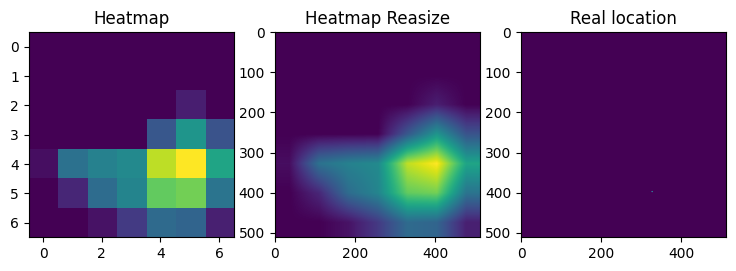

In [ ]:
# Tamaño de la imagen original (altura, ancho)
img_shape = (512, 512)

yolo_nodules = read_txt(f'/content/test/labels/{test_data[0].replace(".jpg", ".txt")}')
ground_truth_mask = yolo_to_mask(yolo_nodules[0], img_shape)

# Supongamos que grad_cam_output es la matriz generada por Grad-CAM con forma (14x14)
heatmap_resized = cv2.resize(heatmap, (512, 512))

# Normalizamos para que los valores de grad_cam_resized estén en [0, 1]
heatmap_resized = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized))

plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(heatmap, cmap='viridis')
plt.title("Heatmap")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap='viridis') # ground_truth_mask * 255
plt.title("Heatmap Reasize")

plt.subplot(1, 3, 3)
plt.imshow(ground_truth_mask, cmap='viridis')
plt.title("Real location")

plt.show()

In [ ]:
binary_grad_cam = binarize_grad_cam(heatmap_resized, threshold=0.5)
iou = calculate_iou(binary_grad_cam, ground_truth_mask)
print(iou)

1


##### Proceso y resultados

In [ ]:
img_shape = (512, 512)
iou_result = []

for label in total_iou_data:
  # Load the image
  load_image = cv2.imread(f'/content/test/images/{label.replace("txt", "jpg")}')
  img = cv2.cvtColor(load_image, cv2.COLOR_BGR2RGB)
  img = cv2.resize(img, (224, 224))
  img = cv2.normalize(img, None, 0, 1.0, cv2.NORM_MINMAX, dtype = cv2.CV_32F)

  # reshape img to a tensor of shape (1, 128, 128, 3)
  imgAsTensor = img.reshape((1, img.shape[0], img.shape[1], img.shape[2]))

  # generate the heatmap
  # heatmap = gCamXception.compute_heatmap(imgAsTensor)
  heatmap = gCamVgg.compute_heatmap(imgAsTensor)

  # Supongamos que grad_cam_output es la matriz generada por Grad-CAM con forma (14x14)
  heatmap_resized = cv2.resize(heatmap, (512, 512))
  # Normalizamos para que los valores de grad_cam_resized estén en [0, 1]
  heatmap_resized = (heatmap_resized - np.min(heatmap_resized)) / (np.max(heatmap_resized) - np.min(heatmap_resized))

  real_nodules = read_txt(f'/content/test/labels/{label}')

  for real_nodule in real_nodules:

    ground_truth_mask = yolo_to_mask(real_nodule, img_shape)
    binary_grad_cam = binarize_grad_cam(heatmap_resized, threshold=0.5)
    iou = calculate_iou(binary_grad_cam, ground_truth_mask)

    iou_result.append(iou)


In [ ]:
media = sum(iou_result) / len(iou_result) # VGG16
print(len(iou_result))
print(iou_result)
print(media)

120
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.14166666666666666


In [ ]:
media = sum(iou_result) / len(iou_result) #Xception
print(len(iou_result))
print(iou_result)
print(media)

120
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]
0.19166666666666668
